In [3]:
import requests
from io import BytesIO
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import pickle as pkl
import networkx as nx
import seaborn as sns
import scipy.stats as stats
np.random.seed(8888)
from scipy.spatial.distance import cdist
import lap
from numpy import linalg as LA
from multiprocessing import cpu_count

from sklearn.metrics.pairwise import pairwise_kernels

import graspologic
from graspologic.inference import latent_distribution_test
from graspologic.embed import AdjacencySpectralEmbed, OmnibusEmbed
from graspologic.simulations import sbm, rdpg
from graspologic.utils import symmetrize
from graspologic.plot import heatmap, pairplot

import igraph as ig
from igraph import *
from scipy.stats import norm
from scipy.sparse import csr_array
from sklearn.metrics import adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform


%matplotlib inline

In [276]:
def aseoos(Xhat, avec):
    n = Xhat.shape[0]
    
    if len(avec) != n:
        raise ValueError("Length of edge vector avec does not match size of latent position matrix Xhat.")
    
    # solve Xhat @ ooshat = avec
    # (really we're solving the linear least squares)
    ooshat = np.linalg.lstsq(Xhat.T @ Xhat, Xhat.T @ avec, rcond=None)[0]
    
    return ooshat

def array_split(data, m):
    rowIdx = np.arange(data.shape[0])
    # Split row indices into m groups
    split_indices = np.array_split(rowIdx, m)
    
    # Use the split indices to split the data array
    split_data = [data[x, :] for x in split_indices]
    
    return split_data

def check_repeated_rows(df):
    # Use duplicated() method to check for repeated rows
    duplicated_rows = df[df.duplicated()]
    if not duplicated_rows.empty:
        print("There are repeated rows.")
        print(duplicated_rows)
        print('numer is',duplicated_rows.shape )
    else:
        print("No repeated rows.")

def find_smallest_columns(row, num):# edit the k for softmatching
    return np.array(row.nsmallest(num).index)

def soft_matching_estimate(dists, oosB,vertex_shuffled,dim, num):
    dists_df = pd.DataFrame(dists)
    #ranked_df = dists_df.rank(axis=1, method='min')  # Using 'min' method for ranking
    dists_df.columns = [vertex_shuffled] #vertex_shuffled2
    dists_df.index = [vertex_shuffled]  
    #sorted_df = pd.DataFrame(np.sort(dists, axis=1), index=dists_df.index, columns=dists_df.columns)
    #check_repeated_rows(dists_df)
    smallest_columns = dists_df.apply(find_smallest_columns, axis=1, num = num)
    flattened_5cols = []
    for row in smallest_columns:
        flattened_5cols.append([item[0] for item in row])
    oosB_df = pd.DataFrame(oosB)
    oosB_df.index = [vertex_shuffled] 
    oosB_avg = np.zeros((len(vertex_shuffled), dim))
    for i in range(len(vertex_shuffled)):
        avg = np.array(oosB_df.loc[flattened_5cols[i]].mean())
        oosB_avg[i,:] = avg

    return oosB_avg

def pairwise_distances(embeddings):
    n = len(embeddings)
    distances = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            norm = LA.norm(embeddings[i] - embeddings[j], ord='fro') ** 2
            distances[i, j] = norm
            distances[j, i] = norm 
    return distances

In [270]:
# disimilarity matrix only for each dataset
eng_dis = pd.read_csv("~/Desktop/papersandbooks/codes/shuffle/data/en.csv",header=None)
zulu_dis = pd.read_csv("~/Desktop/papersandbooks/codes/shuffle/data/zu.csv",header=None)
# print(eng_dis.shape)
# print(zulu_dis.shape)
# print(eng.head(2))
# print(zulu.head(2))

In [30]:
test = pd.read_pickle('./data/train.bpe-30000_top1000.clean.en.pkl')
test2 = pd.read_pickle('./data/train.bpe-30000_top1000.humantranslations.zu.pkl')
eng_df = pd.DataFrame(test)
zulu_df = pd.DataFrame(test2)

In [449]:
print(eng_df.shape)
print(zulu_df.shape)
# print(eng_df.head(2))
# print(zulu_df.head(2))

(1000, 768)
(1000, 768)


In [42]:
from sklearn.metrics.pairwise import cosine_similarity
cos_eng = cosine_similarity(eng_df)
cos_zulu = cosine_similarity(zulu_df)
print(cos_eng.shape) 
print(cos_zulu.shape) 

(1000, 1000)
(1000, 1000)


In [399]:
n = len(cos_eng)
kshuff = np.array([100,200,300,400,500]) #np.array([20,50,100])#np.array([100,200,300,400,500]) 
dims = [10,50,100,200]  #[10,20,30]  #[50,100,200]#[10,20,30] 
nMC = 200 
num = 1 # k for soft matching k=1,3,5,10 (10 and 50 for n=10000,100000)
stats = {}

In [450]:
for dim in dims:    
    acc = np.zeros((nMC, len(kshuff)))
    softmatch_acc = np.zeros((nMC, len(kshuff)))
    for h in range(nMC):
        for j in range(len(kshuff)):
            adj1 = cos_eng
            order_original = np.arange(0, n)
            vertex_shuffled = np.random.choice(order_original, kshuff[j], replace=False)

            np.random.shuffle(vertex_shuffled)

            unshuf = [item for item in order_original if item not in vertex_shuffled]
            reorder_vertex = np.concatenate((unshuf, vertex_shuffled))

            adj2 = cos_zulu[reorder_vertex, :][:, reorder_vertex]

            MA =  adj1[unshuf, :][:, unshuf]
            MB = adj2[0:(n-kshuff[j]), :][:, 0:(n-kshuff[j])]

            omni_embedder = OmnibusEmbed(n_components = dim)
            Zhats12 = omni_embedder.fit_transform([MA, MB])
            MA_xhat = Zhats12[0]
            MB_xhat = Zhats12[1]

            # add this part 
            remaining_indices = np.setdiff1d(order_original, unshuf)
            MA_remain = adj1[remaining_indices,:][ :,unshuf]  #adj1[remaining_indices, :(n-kshuff[j])]
            MB_remain = adj2[-kshuff[j]:, :(n-kshuff[j])]
            

            oosA = np.zeros((kshuff[j], dim))
            for i in range(kshuff[j]):
                #shuffle_vector = adj1[n-kshuff[j]+i, :(n-kshuff[j])] # and this part
                shuffle_vector = MA_remain[i,:]
                point_est = aseoos(MA_xhat, shuffle_vector)
                oosA[i, :] = point_est

            oosB = np.zeros((kshuff[j], dim))
            for i in range(kshuff[j]):
                #shuffle_vector = adj2[n-kshuff[j]+i, :(n-kshuff[j])]
                shuffle_vector = MB_remain[i,:]
                point_est = aseoos(MB_xhat, shuffle_vector)
                oosB[i, :] = point_est

            dists = cdist(oosA,oosB, 'euclidean') 
            cost, x1, y1 = lap.lapjv(dists) 
            oosB_2 = oosB[x1] 

            oosB_avg = soft_matching_estimate(dists,oosB,vertex_shuffled, dim = dim, num = num)

            correct_matches = np.sum(remaining_indices == np.take(vertex_shuffled, x1))
            acc[h,j] = correct_matches/kshuff[j]

            num_best_guesses = np.argsort(dists, axis=1)[:, :num]
            matches = np.array([remaining_indices[i] in vertex_shuffled[num_best_guesses[i]] for i in range(kshuff[j])])
            softmatch_acc[h, j] = np.mean(matches)
            
    stats[dim] = {
        "accuracy": acc,
        "softmatch_acc": softmatch_acc}


ValueError: Cannot take a larger sample than population when 'replace=False'

In [456]:
stats[10]['accuracy'].shape

(200, 5)

In [401]:
# # print(x1)
# # print(np.take(vertex_shuffled, x1))
# print(vertex_shuffled)
# print(remaining_indices)
# # correct_matches = np.sum(remaining_indices == np.take(vertex_shuffled, x1))
# # print(correct_matches/kshuff[j])
# matches = np.array([remaining_indices[i] in vertex_shuffled[num_best_guesses[i]] for i in range(len(kshuff))])
# print(matches)
# np.mean(matches)

In [402]:
acc_values = {k: [] for k in kshuff}
acc_vars = {k: [] for k in kshuff}
softm_means = {k: [] for k in kshuff}
softm_vars = {k: [] for k in kshuff}
for key, matrices in stats.items():
    print(key)
    spearman_mean = np.mean(matrices['accuracy'], axis=0)
    spearman_var = np.var(matrices['accuracy'], axis=0)
    softm_mean = np.mean(matrices['softmatch_acc'], axis=0)
    softm_var = np.var(matrices['softmatch_acc'], axis=0)
    print(f"Spearman_mean:  {spearman_mean}")
    print(f"spearman_var: {spearman_var}")
    print(f"softm_mean: {softm_mean}")
    print(f"softm_var: {softm_var}")
    for i, k in enumerate(kshuff):
        acc_values[k].append(spearman_mean[i])
        acc_vars[k].append(spearman_var[i])
        softm_means[k].append(softm_mean[i])
        softm_vars[k].append(softm_var[i])


data = {
    f'spearman_value_{k}': acc_values[k] for k in kshuff
} | {
    f'spearman_var_{k}': acc_vars[k] for k in kshuff
} | {
    f'softm_means{k}': softm_means[k] for k in kshuff
} | {
    f'softm_vars{k}': softm_vars[k] for k in kshuff
} 
df = pd.DataFrame(data,index=dims)

10
Spearman_mean:  [0.16905    0.1102     0.08596667 0.06835    0.05712   ]
spearman_var: [0.0013806  0.00056446 0.00029307 0.00018671 0.00010231]
softm_mean: [0.1227     0.080475   0.06048333 0.0465     0.03963   ]
softm_var: [6.79710000e-04 3.22149375e-04 1.67488611e-04 7.87500000e-05
 6.28431000e-05]
50
Spearman_mean:  [0.352    0.264975 0.22335  0.185    0.1553  ]
spearman_var: [0.003235   0.00089287 0.00055817 0.00030763 0.00024483]
softm_mean: [0.2743     0.208025   0.17111667 0.141975   0.11863   ]
softm_var: [0.00160051 0.00073972 0.0003517  0.00020291 0.00016822]
100
Spearman_mean:  [0.37085    0.279225   0.23228333 0.197275   0.17376   ]
spearman_var: [0.00290578 0.00089577 0.00062084 0.00037682 0.00032562]
softm_mean: [0.2882     0.21245    0.18086667 0.154175   0.13461   ]
softm_var: [0.00163376 0.00063125 0.00039892 0.00023388 0.00018817]
200
Spearman_mean:  [0.3541  0.2871  0.2403  0.20345 0.16923]
spearman_var: [0.00254419 0.00094759 0.00048391 0.00039603 0.00024115]
sof

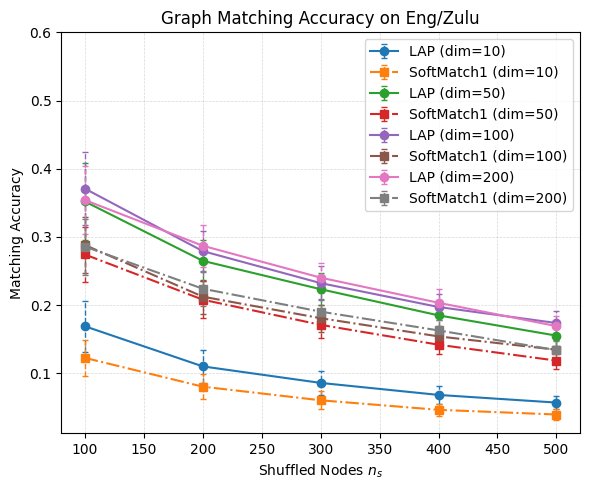

In [409]:
plt.figure(figsize=(6, 5))

for dim in df.index:
    # Extract y-values and errors for each metric
    spearman_y = [df.loc[dim, f'spearman_value_{k}'] for k in kshuff]
    spearman_err = [np.sqrt(df.loc[dim, f'spearman_var_{k}']) for k in kshuff]
    
    softm_y = [df.loc[dim, f'softm_means{k}'] for k in kshuff]
    softm_err = [np.sqrt(df.loc[dim, f'softm_vars{k}']) for k in kshuff]

    # Plot LAP
    eb1 = plt.errorbar(kshuff, spearman_y, yerr=spearman_err,
                 label=fr'LAP (dim={dim})', marker='o', linestyle='-',
                 capsize=2, elinewidth=1)
    eb1[-1][0].set_linestyle('--')
    
    # Plot SoftMatch
    eb2 = plt.errorbar(kshuff, softm_y, yerr=softm_err,
                 label=fr'SoftMatch{num} (dim={dim})', marker='s', linestyle='-.',
                 capsize=2, elinewidth=1)
    eb2[-1][0].set_linestyle('--')

# Axis labels and formatting
plt.xlabel(r'Shuffled Nodes $n_s$')
plt.ylabel('Matching Accuracy')
plt.title('Graph Matching Accuracy on Eng/Zulu')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.ylim(top=0.6)
plt.legend()
plt.tight_layout()
plt.show()

## plot the HPC results

In [447]:
test = pd.read_csv('~/Desktop/papersandbooks/codes/shuffle/data/HPC_results_n_10000_soft5.csv')
test

,spearman_value_500,spearman_value_1500,spearman_value_3000,spearman_var_500,spearman_var_1500,spearman_var_3000,softm_means500,softm_means1500,softm_means3000,softm_vars500,softm_vars1500,softm_vars3000
0,0.75798,0.421547,0.228030,0.001110,0.000253,0.000081,0.96250,0.800973,0.579487,0.000088,0.000086,0.000128
1,0.81662,0.494700,0.275737,0.000618,0.000264,0.000079,0.96128,0.815120,0.598463,0.000075,0.000118,0.000077
2,0.74148,0.435167,0.230460,0.000673,0.000222,0.000082,0.92162,0.740960,0.507030,0.000119,0.000126,0.000111
3,0.60444,0.325913,0.161397,0.000792,0.000175,0.000037,0.84256,0.608580,0.373657,0.000314,0.000186,0.000081
4,0.44540,0.215400,0.093857,0.000755,0.000142,0.000036,0.70942,0.444173,0.230523,0.000377,0.000165,0.000074
5,0.26418,0.107527,0.033197,0.000496,0.000078,0.000013,0.50374,0.249560,0.089957,0.000663,0.000162,0.000053


,spearman_value_500,spearman_value_1500,spearman_value_3000,spearman_var_500,spearman_var_1500,spearman_var_3000,softm_means500,softm_means1500,softm_means3000,softm_vars500,softm_vars1500,softm_vars3000
4,0.75798,0.421547,0.228030,0.001110,0.000253,0.000081,0.96250,0.800973,0.579487,0.000088,0.000086,0.000128
6,0.81662,0.494700,0.275737,0.000618,0.000264,0.000079,0.96128,0.815120,0.598463,0.000075,0.000118,0.000077
8,0.74148,0.435167,0.230460,0.000673,0.000222,0.000082,0.92162,0.740960,0.507030,0.000119,0.000126,0.000111
10,0.60444,0.325913,0.161397,0.000792,0.000175,0.000037,0.84256,0.608580,0.373657,0.000314,0.000186,0.000081
12,0.44540,0.215400,0.093857,0.000755,0.000142,0.000036,0.70942,0.444173,0.230523,0.000377,0.000165,0.000074
14,0.26418,0.107527,0.033197,0.000496,0.000078,0.000013,0.50374,0.249560,0.089957,0.000663,0.000162,0.000053


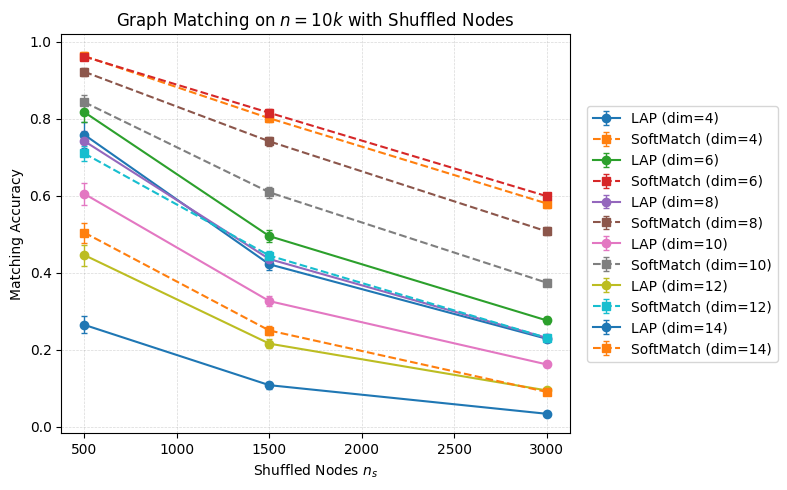

In [432]:
kshuff = [500, 1500, 3000]
dim = [4,6,8,10,12,14] 
test.index = dim

plt.figure(figsize=(8, 5))

# Iterate over each row in the DataFrame (e.g., if each row is a different 'dim')
for idx in test.index:
    # Extract values and variances for this row
    spearman_y = [test.loc[idx, f'spearman_value_{k}'] for k in kshuff]
    spearman_err = [np.sqrt(test.loc[idx, f'spearman_var_{k}']) for k in kshuff]

    softm_y = [test.loc[idx, f'softm_means{k}'] for k in kshuff]
    softm_err = [np.sqrt(test.loc[idx, f'softm_vars{k}']) for k in kshuff]

    # Plot spearman
    plt.errorbar(kshuff, spearman_y, yerr=spearman_err,
                 label=f'LAP (dim={idx})', marker='o', linestyle='-',
                 capsize=2, elinewidth=1)

    # Plot softmatch
    plt.errorbar(kshuff, softm_y, yerr=softm_err,
                 label=f'SoftMatch (dim={idx})', marker='s', linestyle='--',
                 capsize=2, elinewidth=1)

# Axis labels and formatting
plt.xlabel(r'Shuffled Nodes $n_s$')
plt.ylabel('Matching Accuracy')
plt.title(r'Graph Matching on $n = 10k$ with Shuffled Nodes')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
#plt.legend()
plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

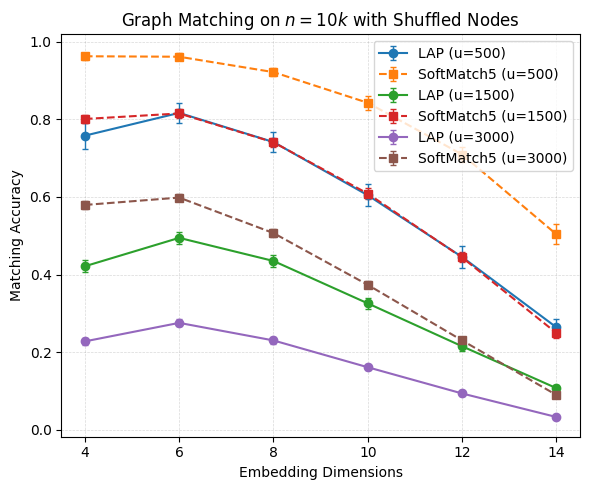

In [448]:
kshuff = [500, 1500, 3000]
dims = [4, 6, 8, 10, 12, 14] 
test.index = dims  # Ensure correct indexing

plt.figure(figsize=(6, 5))

# Iterate over each kshuff value to draw a line across dims
for k in kshuff:
    # Extract values and errors across dims
    spearman_y = [test.loc[dim, f'spearman_value_{k}'] for dim in dims]
    spearman_err = [np.sqrt(test.loc[dim, f'spearman_var_{k}']) for dim in dims]

    softm_y = [test.loc[dim, f'softm_means{k}'] for dim in dims]
    softm_err = [np.sqrt(test.loc[dim, f'softm_vars{k}']) for dim in dims]

    # Plot Spearman LAP
    plt.errorbar(dims, spearman_y, yerr=spearman_err,
                 label=f'LAP (u={k})', marker='o', linestyle='-',
                 capsize=2, elinewidth=1)

    # Plot SoftMatch
    plt.errorbar(dims, softm_y, yerr=softm_err,
                 label=f'SoftMatch5 (u={k})', marker='s', linestyle='--',
                 capsize=2, elinewidth=1)

# Axis labels and formatting
plt.xlabel('Embedding Dimensions')
plt.ylabel('Matching Accuracy')
plt.title(r'Graph Matching on $n = 10k$ with Shuffled Nodes')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
#plt.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
plt.legend()
plt.tight_layout()
plt.show()

In [418]:
len(vertex_shuffled)

500

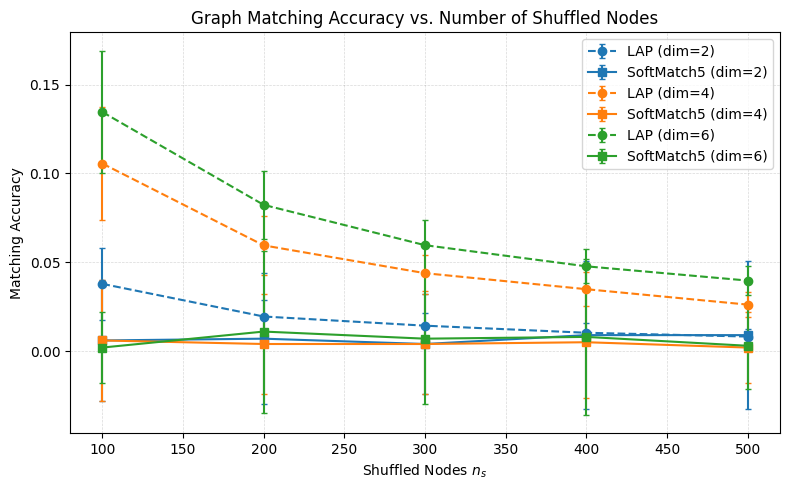

In [184]:
# Assign a color for each dimension
import matplotlib.cm as cm
colors = cm.tab10(np.linspace(0, 0.2, len(dims)))

# Plotting
plt.figure(figsize=(8, 5))

for i, dim in enumerate(df.index):
    color = colors[i]

    # Spearman
    spearman_y = [df.loc[dim, f'spearman_value_{k}'] for k in kshuff]
    spearman_err = [np.sqrt(df.loc[dim, f'spearman_var_{k}']) for k in kshuff]
    plt.errorbar(kshuff, spearman_y, yerr=spearman_err,
                 label=fr'LAP (dim={dim})',
                 color=color, marker='o', linestyle='--', capsize=2)

    # SoftMatch
    softm_y = [df.loc[dim, f'softm_means{k}'] for k in kshuff]
    softm_err = [np.sqrt(df.loc[dim, f'softm_vars{k}']) for k in kshuff]
    plt.errorbar(kshuff, softm_y, yerr=softm_err,
                 label=fr'SoftMatch{num} (dim={dim})',
                 color=color, marker='s', linestyle='-', capsize=2)

# Final touches
plt.xlabel(r'Shuffled Nodes $n_s$')
plt.ylabel('Matching Accuracy')
plt.title('Graph Matching Accuracy vs. Number of Shuffled Nodes')
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

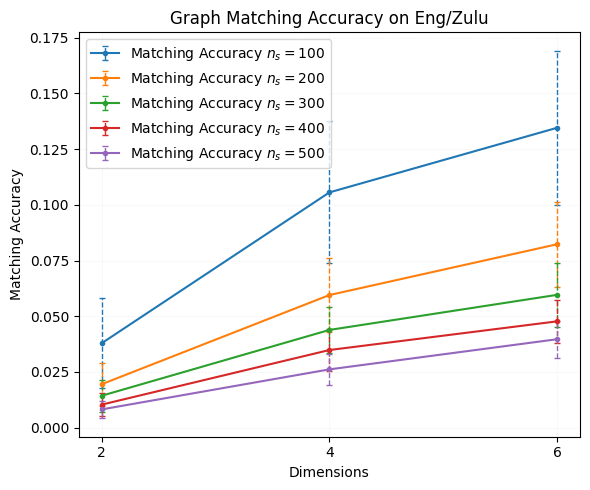

In [164]:
plt.figure(figsize=(6, 5))

for k in kshuff:
    eb = plt.errorbar(
        df.index,
        df[f'spearman_value_{k}'],
        yerr=np.sqrt(df[f'spearman_var_{k}']),
        label=fr'Matching Accuracy $n_s = {k}$',
        marker='o',
        markersize=3,
        elinewidth=1,
        capsize=2,
        errorevery=1
    )
    eb[-1][0].set_linestyle('--')

plt.xlabel('Dimensions')
plt.ylabel('Matching Accuracy')
# plt.title(f'Graph Matching on $n = {int(n / 1000)}k$ with Shuffled Nodes')
plt.title("Graph Matching Accuracy on Eng/Zulu")
plt.xticks(df.index)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.1)
plt.legend()
plt.tight_layout()
plt.show()

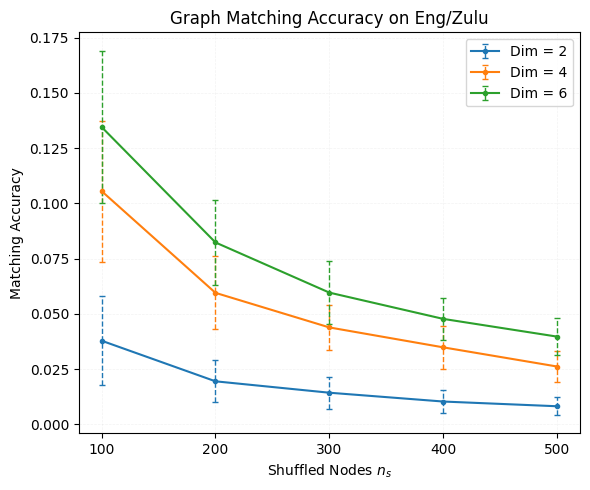

In [165]:
dimensions = df.index
long_data = []

for k in kshuff:
    for dim in dimensions:
        long_data.append({
            'dimension': dim,
            'kshuff': k,
            'value': df.loc[dim, f'spearman_value_{k}'],
            'stderr': np.sqrt(df.loc[dim, f'spearman_var_{k}']),
        })

long_df = pd.DataFrame(long_data)

plt.figure(figsize=(6, 5))

for dim in sorted(long_df['dimension'].unique()):
    data = long_df[long_df['dimension'] == dim]
    eb = plt.errorbar(
        data['kshuff'],
        data['value'],
        yerr=data['stderr'],
        label=fr'Dim = {dim}',
        marker='o',
        markersize=3,
        elinewidth=1,
        capsize=2,
        errorevery=1
    )
    eb[-1][0].set_linestyle('--')

plt.xlabel(r'Shuffled Nodes $n_s$')
plt.ylabel('Matching Accuracy')
# plt.title(f'Graph Matching on $n = {int(n / 1000)}k$ vs Shuffled Nodes')
plt.title("Graph Matching Accuracy on Eng/Zulu")
plt.xticks(kshuff)
plt.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.1)
plt.legend()
plt.tight_layout()
plt.show()

In [166]:
long_df

,dimension,kshuff,value,stderr
0,2,100,0.037850,0.020146
1,4,100,0.105550,0.031870
2,6,100,0.134550,0.034566
3,2,200,0.019475,0.009545
4,4,200,0.059500,0.016470
5,6,200,0.082300,0.019156
6,2,300,0.014317,0.007210
7,4,300,0.043850,0.010275
8,6,300,0.059600,0.014320
9,2,400,0.010325,0.005293


In [129]:
adj1 = cos_eng
order_original = np.arange(0, n)
vertex_shuffled = np.random.choice(order_original, kshuff[j], replace=False)

np.random.shuffle(vertex_shuffled)

unshuf = [item for item in order_original if item not in vertex_shuffled]
reorder_vertex = np.concatenate((unshuf, vertex_shuffled))

adj2 = cos_zulu[reorder_vertex, :][:, reorder_vertex]

MA =  adj1[unshuf, :][:, unshuf] # unshuffled rows
MB = adj2[0:(n-kshuff[j]), :][:, 0:(n-kshuff[j])] # first rows are unshuffled

omni_embedder = OmnibusEmbed(n_components = dim)
Zhats12 = omni_embedder.fit_transform([MA, MB])
MA_xhat = Zhats12[0]
MB_xhat = Zhats12[1]

# add this part 
remaining_indices = np.setdiff1d(order_original, unshuf) # correct order of the shuffled parts
MA_remain = adj1[remaining_indices,:][ :,unshuf]  #adj1[remaining_indices, :(n-kshuff[j])]
MB_remain = adj2[-kshuff[j]:, :(n-kshuff[j])]

oosA = np.zeros((kshuff[j], dim))
for i in range(kshuff[j]):
    #shuffle_vector = adj1[n-kshuff[j]+i, :(n-kshuff[j])] # and this part
    shuffle_vector = MA_remain[i,:]
    point_est = aseoos(MA_xhat, shuffle_vector)
    oosA[i, :] = point_est

oosB = np.zeros((kshuff[j], dim))
for i in range(kshuff[j]):
    #shuffle_vector = adj2[n-kshuff[j]+i, :(n-kshuff[j])]
    shuffle_vector = MB_remain[i,:]
    point_est = aseoos(MB_xhat, shuffle_vector)
    oosB[i, :] = point_est

dists = cdist(oosA, oosB, 'euclidean')
cost, x1, y1 = lap.lapjv(dists)
oosB_2 = oosB[x1]

oosB_avg = soft_matching_estimate(dists,oosB,vertex_shuffled, dim = dim)

correct_matches = np.sum(remaining_indices == np.take(vertex_shuffled, x1))
acc[h,j] = correct_matches/kshuff[j]

# # Soft matching accuracy (bc averages, so need to find closest vertex) (when the true match is in the top k guesses in oosB_avg)
# soft_dists = cdist(oosA, oosB_avg, 'euclidean')  
num_best_guesses = np.argsort(dists, axis=1)[:, :num]
matches = np.array([remaining_indices[i] in num_best_guesses[i] for i in range(len(remaining_indices))]) # find how many in oosB_avg were matched to one of the k best
softmatch_acc[h, j] = np.mean(matches)

In [130]:
acc


array([[0. ],
       [0.1]])

In [132]:
softmatch_acc

array([[0.        ],
       [0.00333333]])

In [128]:
matches = np.array([remaining_indices[i] in num_best_guesses[i] for i in range(len(remaining_indices))])
np.mean(matches)

0.0

In [115]:
num_best_guesses.shape

(300, 3)

In [80]:
closest_indices = np.argsort(dists)[:num]
closest_indices

array([[ 36, 162, 289, 174, 272,  34, 192, 188, 119, 180, 142, 131,  90,
        143, 159,   3, 253, 202,  86, 173, 249, 242,  58,  21, 160, 217,
        222, 177,  70, 130, 239,  83, 163,  53, 123,  56,  66,  22, 172,
        292, 256, 257, 277,  16, 282, 225,  19, 248,   1, 175,  65, 121,
        212, 144, 113, 226, 268,  28, 207, 246, 213,  57, 252, 214, 107,
        197,  49, 183, 294, 109, 167, 125, 110, 298, 260,  94, 265, 293,
         81, 204,  50, 216,   8, 189, 208, 287, 258, 134,  68,  79,  17,
        233, 169,  97, 285, 245, 117, 196, 215, 231, 176,  67, 179, 263,
        156, 115, 193, 132, 221, 210, 276, 238,  26,  60,  42, 295, 154,
        269,  25,  30,  55, 120, 227, 166,   7, 274, 279, 158,  15, 284,
         96, 244, 266, 184, 206, 195, 198, 149, 224,  88, 199, 133, 135,
        288,   5, 186, 205, 122, 108, 105,  39,  63, 190,  74, 178,  82,
         14, 211, 129,  37, 126, 155, 124, 254,  52, 250,  47,  29, 152,
        209, 146,  11, 181, 273, 168, 191, 243,  59

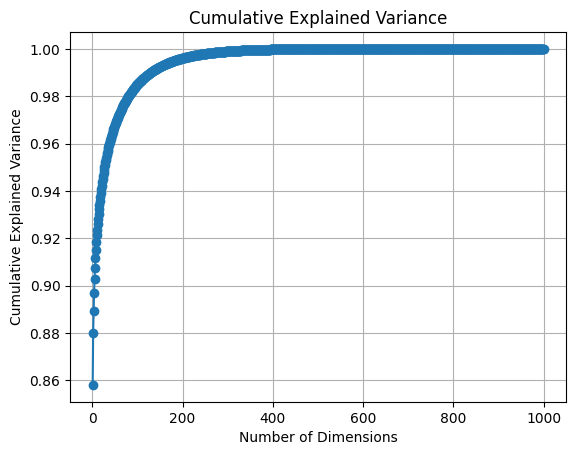

The elbow is at dimension: 2


In [138]:
U, S, Vt = np.linalg.svd(cos_eng, full_matrices=False)

# Compute the explained variance (squared singular values)
explained_variance = (S ** 2) / np.sum(S ** 2)

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative variance
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Dimensions')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()

# Find the elbow point (a common heuristic)
elbow_index = np.argmax(np.diff(cumulative_variance) < 0.01)  # or some threshold
print(f"The elbow is at dimension: {elbow_index + 1}")

In [245]:
times = [(0,40),(5,10),(15,20)] # start time, end time for meeting 
# give the number of meeting rooms

In [249]:
import heapq
def num_rooms(times):
    times.sort(key= lambda x: x[0])
    heap = [] # get the endding time
    for time in times:
        if heap and heap[0] <= time[0]: # no conflict
            heapq.heappop(heap)
        heapq.heappush(heap, time[1]) # conflict 
    
    return len(heap)


In [250]:
num_rooms(times)

2

# Fast embedding

In [419]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/Users/tongqi/miniforge3/lib/python3.9/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <EF10DC06-064E-3614-96B8-350E8279C9FD> /Users/tongqi/miniforge3/lib/python3.9/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


MemoryError: Cannot allocate write+execute memory for ffi.callback(). You might be running on a system that prevents this. For more information, see https://cffi.readthedocs.io/en/latest/using.html#callbacks